In [2]:
# Step 1: Import required libraries

import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from src.preprocessing import preprocess_data

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Step 2: Load and preprocess data

X_train, X_test, y_train, y_test = preprocess_data(
    "../data/online_gaming_behavior_dataset.csv"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("Class distribution:\n", y_train.value_counts(normalize=True))
print(y_train.unique())

Training shape: (37203, 18)
Testing shape: (8007, 18)
Class distribution:
 EngagementLevel
Medium    0.333333
Low       0.333333
High      0.333333
Name: proportion, dtype: float64
<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str


In [4]:
# Step 3: Train baseline model

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [5]:
# Step 4: Evaluate baseline model

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8323966529286874

Classification Report:
               precision    recall  f1-score   support

        High       0.86      0.89      0.87      2067
         Low       0.72      0.87      0.79      2065
      Medium       0.90      0.78      0.84      3875

    accuracy                           0.83      8007
   macro avg       0.83      0.85      0.83      8007
weighted avg       0.84      0.83      0.83      8007



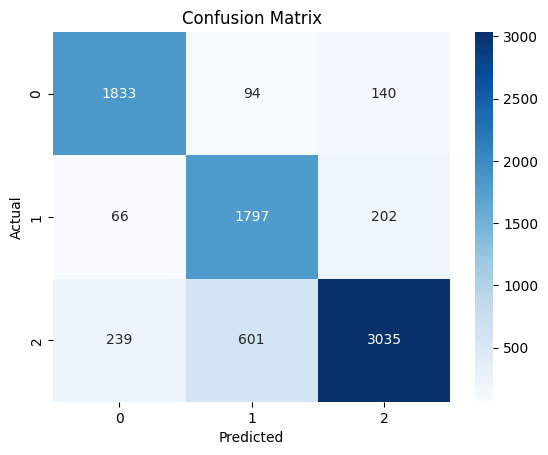

In [6]:
# Step 5: Confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                      Feature  Importance
7         TotalWeeklyPlayTime    2.545338
3             SessionsPerWeek    0.715879
4   AvgSessionDurationMinutes    0.604742
6        AchievementsUnlocked    0.172708
5                 PlayerLevel    0.143160
1               PlayTimeHours    0.030395
9             Location_Europe    0.024143
15         GameGenre_Strategy    0.015068
11               Location_USA    0.014834
10             Location_Other    0.010312


<Figure size 640x480 with 0 Axes>

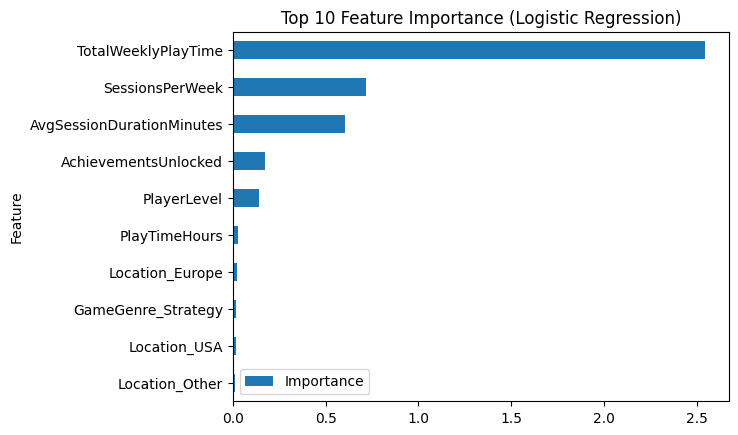

In [7]:
# Step 6: Feature importance (coefficients)

coef = log_model.coef_

# For multiclass, take mean importance
importance = np.mean(np.abs(coef), axis=0)

feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

plt.figure()
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

In [8]:
# Step 7: Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 10, 'solver': 'lbfgs'}


In [9]:
# Step 8: Evaluate optimized model

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

from sklearn.metrics import f1_score, precision_score, recall_score

print("F1 Score:", f1_score(y_test, y_pred_best, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_best, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_best, average='weighted'))

Optimized Accuracy: 0.8326464343699264

Classification Report:
               precision    recall  f1-score   support

        High       0.86      0.89      0.87      2067
         Low       0.72      0.87      0.79      2065
      Medium       0.90      0.78      0.84      3875

    accuracy                           0.83      8007
   macro avg       0.83      0.85      0.83      8007
weighted avg       0.84      0.83      0.83      8007

F1 Score: 0.8338015815792005
Precision: 0.8425129036881827
Recall: 0.8326464343699264


In [10]:
# Step 9: ROC AUC

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

y_prob = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("ROC AUC (OvR):", roc_auc)

ROC AUC (OvR): 0.9304742245905797


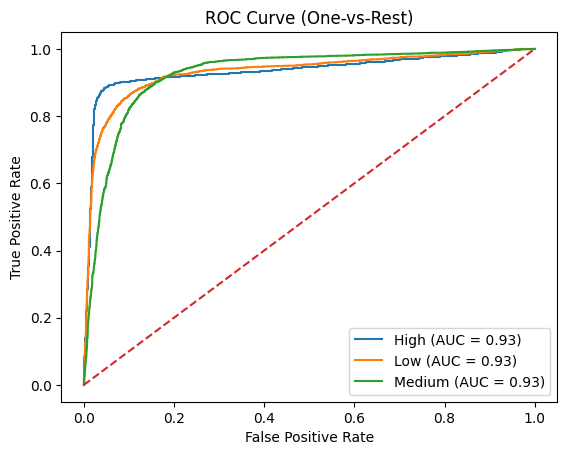

In [11]:
# Step 10: ROC Curve

from sklearn.metrics import roc_curve, auc

plt.figure()

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [12]:
# Step 11: Model Testing

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

sample_df = X_test_reset.sample(10, random_state=42)
sample_y = y_test_reset.iloc[sample_df.index]

sample_pred = best_model.predict(sample_df)

results_df = pd.DataFrame({
    "Actual": sample_y.values,
    "Predicted": sample_pred
})

results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]

print(results_df)

sample_accuracy = (results_df["Correct"].sum() / len(results_df)) * 100
print(f"\nSample Accuracy: {sample_accuracy:.2f}%")

   Actual Predicted  Correct
0  Medium       Low    False
1    High      High     True
2  Medium    Medium     True
3    High      High     True
4     Low       Low     True
5    High      High     True
6  Medium    Medium     True
7  Medium    Medium     True
8  Medium    Medium     True
9    High      High     True

Sample Accuracy: 90.00%


In [13]:
# Save results to CSV

results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, average='weighted'),
    "Recall": recall_score(y_test, y_pred_best, average='weighted'),
    "F1-score": f1_score(y_test, y_pred_best, average='weighted'),
    "ROC_AUC": roc_auc
}

results_df = pd.DataFrame([results])

results_df.to_csv("../results/logistic_regression.csv", index=False)